# Principal geodesic analysis and spectral decomposition

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pca.bures_wasserstein_principal_geodesic_analysis_vec import BuresWassersteinPGA, BuresWassersteinTPCA
from tools.plot_2d import plot_results, plot_results_1, plot_spd_matrix_translated, plot_results_on_cone
from tools.compute import make_rotation_2d

INFO: Using numpy backend


## PGA on SPD matrices that are diagonalizable in the same basis

The Bures Wasserstein distance between two SPD matrices that are diagonalizable in the same orthonormal basis is the Euclidean distance between the vectors of their eigenvalues square roots. Thus we verify that PGA on a set of SPD matrices that are diagonalizable in the same basis is equivalent to Euclidean PCA on their eigenvalues square roots. We randomly generate diagonal SPD matrices, perform PGA and plot the results. Each SPD matrix is represented by the image of the circle by the linear transformation of the plane induced by the matrix, i.e., an ellipse.

In [13]:
dim = 2
n = 9
e1 = np.linspace(1., np.sqrt(3), n)
e2 = np.linspace(1., np.sqrt(2), n)
ee = np.meshgrid(e1, e2)
eig_sq_roots = np.stack(ee).T.reshape((n ** 2, dim))
points_spd = np.stack([np.diag(eig_sq_roots[i] ** 2) for i in range(n**2)])

success


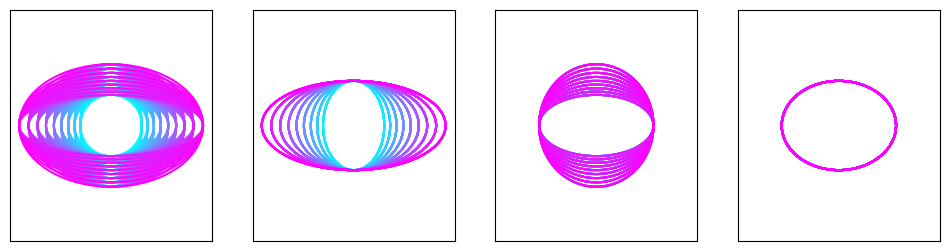

In [14]:
pga = BuresWassersteinPGA(dim=2).fit(points_spd)
print(pga['message'])
%matplotlib inline
plot_results_1(points_spd, pga, alpha=0.)

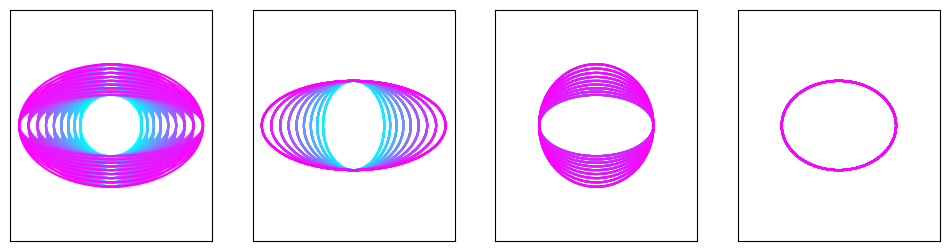

In [15]:
tpca = BuresWassersteinTPCA.fit(points_spd)
plot_results_1(points_spd, tpca, alpha=0.)

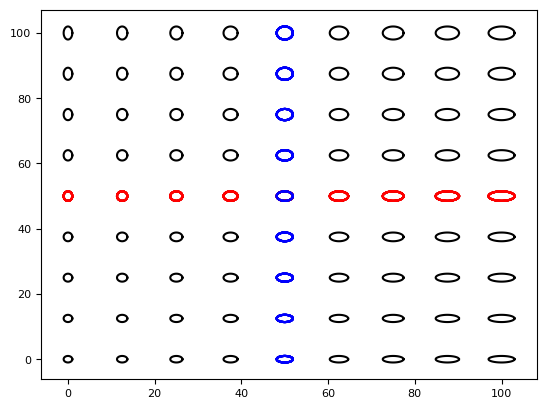

In [16]:
%matplotlib inline
n_transl = 100
x = np.linspace(0., n_transl, n)
xx = np.meshgrid(x, x)
positions = np.stack(xx).T.reshape((n ** 2, dim))
positions_comp1 = np.tile(np.stack((x, n_transl // 2 * np.ones(n))).T, (1,n)).reshape((n**2, 2))
positions_comp2 = np.tile(np.stack((n_transl // 2 * np.ones(n), x)).T, (n,1))
for i in range(n ** 2):
    plot_spd_matrix_translated(points_spd[i], positions[i], color='k')
    plot_spd_matrix_translated(pga['components'][1, i], positions_comp2[i], color='b')
    plot_spd_matrix_translated(pga['components'][0, i], positions_comp1[i], color='r')
plt.show()

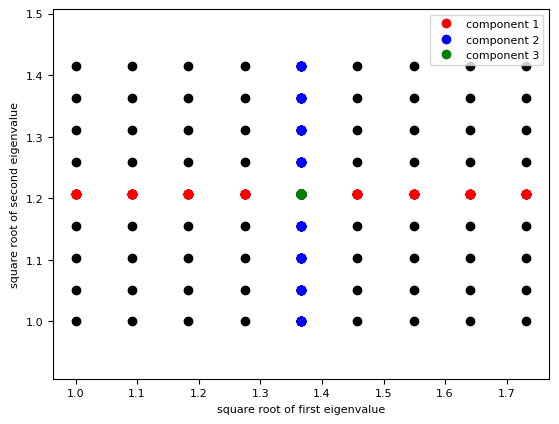

In [17]:
eig_comp1 = np.vstack([np.linalg.eig(mat)[0] for mat in pga['components'][0]])
eig_comp2 = np.vstack([np.linalg.eig(mat)[0] for mat in pga['components'][1]])
eig_comp3 = np.vstack([np.linalg.eig(mat)[0] for mat in pga['components'][2]])

plt.plot(eig_sq_roots[:, 0], eig_sq_roots[:, 1], 'ok')
plt.plot(np.sqrt(eig_comp1[:, 0]), np.sqrt(eig_comp1[:, 1]), 'or', label='component 1')
plt.plot(np.sqrt(eig_comp2[:, 0]), np.sqrt(eig_comp2[:, 1]), 'ob', label='component 2')
plt.plot(np.sqrt(eig_comp3[:, 0]), np.sqrt(eig_comp3[:, 1]), 'og', label='component 3')
plt.axis('equal')
plt.legend()
plt.xlabel('square root of first eigenvalue')
plt.ylabel('square root of second eigenvalue')
plt.show()

We indeed retrieve standard PCA in the space of the eigenvalues square roots.

/Users/alebrigant/PycharmProjects/bures_wasserstein_pga/tools/plot_2d.py:170: RuntimeWarning: divide by zero encountered in scalar divide
  angle = np.arctan(- eigenvec[0, 1] / eigenvec[1, 1])


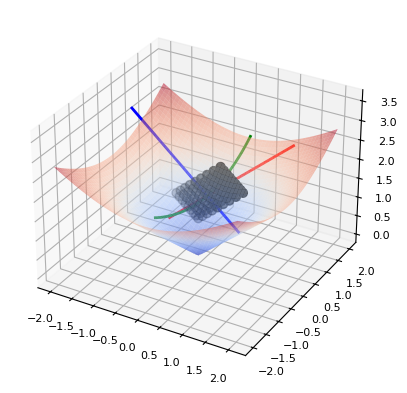

In [18]:
%matplotlib inline

plot_results_on_cone(points_spd, pga, bound=2., t_clip=1.)

In [42]:
%matplotlib inline

## PGA on SPD matrices that have the same eigenvalues

We now randomly generate SPD matrices with the same eigenvalues. They can be represented by the same ellipse rotated by different angles.

In [57]:
np.random.seed(1)

eig_1 = np.random.uniform(high=10)
eig_2 = np.random.uniform(high=10)
print(eig_1, eig_2)

4.17022004702574 7.203244934421581


In [58]:
n_points = 50
angles = np.random.uniform(high=2 * np.pi, size=n_points)
rotations = make_rotation_2d(angles)
diag_mat = np.diag([eig_1, eig_2])
points_spd = np.stack([rot @ diag_mat @ rot.T for rot in rotations])

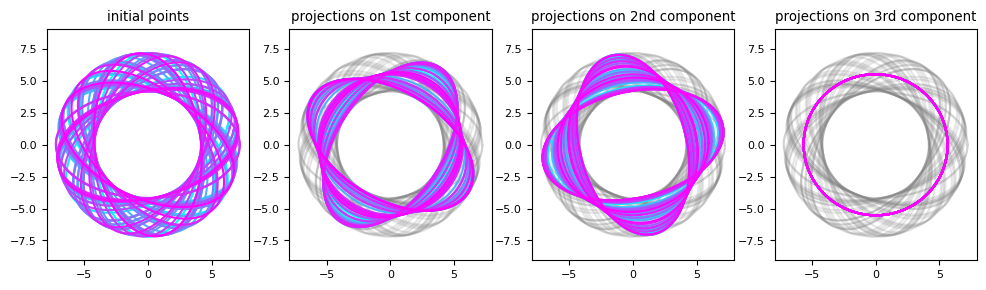

In [61]:
pga = BuresWassersteinPGA(dim=2).fit(points_spd)
plot_results_1(points_spd, pga)

In [62]:
%matplotlib qt

plot_results_on_cone(points_spd, pga, bound=6., t_clip=1.)

In [60]:
%matplotlib inline

## Detection of eigenvalue and rotation variations by the principal components

In [23]:
def spectral_decomposition(mat):
    eig, rot = np.linalg.eigh(mat)
    if np.sum(rot > 0.) == 1:
        rot *= -1
    angle = np.arccos(rot[0, 0])
    return eig, angle

def pga_with_respect_to_spectral_decomposition(n_points, eig_min, eig_max, angle_min, angle_max, seed=None):
    if seed is not None: np.random.seed(seed)

    eig = np.random.uniform(low=eig_min, high=eig_max, size=n_points)
    angles = np.random.uniform(low=angle_min, high=angle_max, size=n_points)
    rotations = make_rotation_2d(angles)
    
    coef = 2
    diag_mats = np.stack([np.diag([eig_i, coef * eig_i]) for eig_i in eig])
    points_spd = np.stack([rot @ diag_mat @ rot.T for (rot, diag_mat) in zip(rotations, diag_mats)])
    
    pca = BuresWassersteinPGA(2).fit(points_spd)
    plot_results_1(points_spd, pca)

    tpca = BuresWassersteinTPCA().fit(points_spd)
    plot_results_1(points_spd, tpca)
    return pca, tpca, points_spd

In [24]:
pca_1, tpca_1, points_spd = pga_with_respect_to_spectral_decomposition(
    n_points=100, 
    eig_min=1., 
    eig_max=1.5, 
    angle_min=-np.pi/6, 
    angle_max=np.pi/6,
    seed=1,
)

In [26]:
%matplotlib qt

plot_results_on_cone(points_spd, pca_1, bound=2., t_clip=.5)

In [27]:
%matplotlib inline

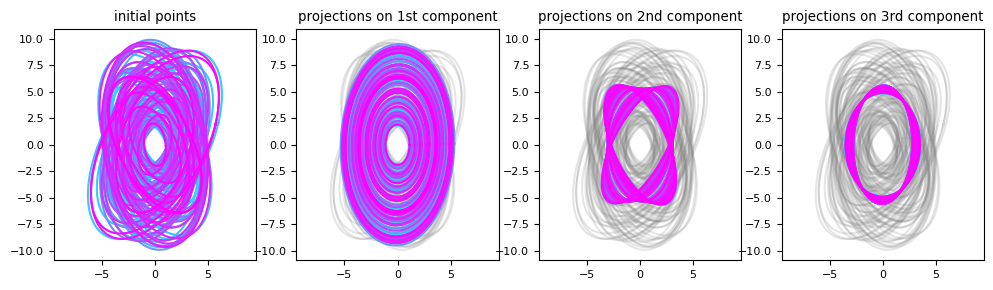

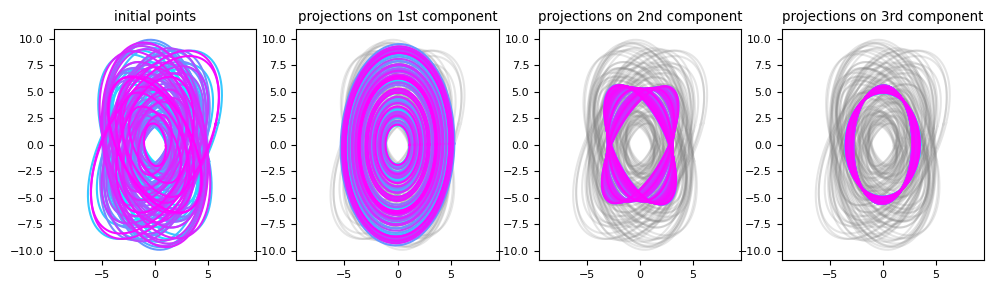

In [28]:
pca_2, tpca_2, points_spd = pga_with_respect_to_spectral_decomposition(
    n_points=100, 
    eig_min=1., 
    eig_max=5., 
    angle_min=-np.pi/6, 
    angle_max=np.pi/6,
    seed=1,
)

In [31]:
%matplotlib qt

plot_results_on_cone(points_spd, pca_2, bound=5., t_clip=1.)

In [34]:
%matplotlib inline

In [14]:
print(pca_1['variances'])
print(tpca_1['variances'][:3])
print(pca_2['variances'])
print(tpca_2['variances'][:3])

[3.60956021 1.33406377 0.23725008]
[3.6039379  1.33385189 0.23147653]
[38.33056581  8.33361094  0.57518947]
[38.33031098  8.3199549   0.56013131]


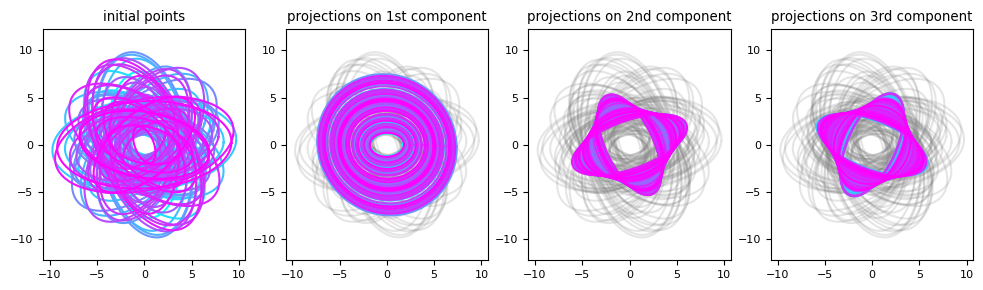

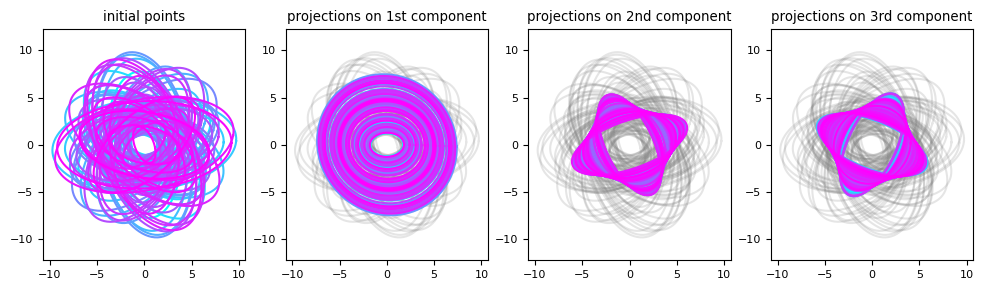

In [15]:
pca_3, tpca_3 = pga_with_respect_to_spectral_decomposition(
    n_points=100, 
    eig_min=1., 
    eig_max=5., 
    angle_min=-np.pi/2, 
    angle_max=np.pi/2,
    seed=1,
)

In [24]:
print(pca_3['costs'])

[24.62090281 47.9940292  51.61898592]
